In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# 결측값의 패턴을 분석하고 다양한 처리 전략을 비교합니다.

In [11]:
# **📋 상세 지시사항:**

# 1. **결측값 분석**
#    - Titanic 데이터의 결측값 시각화
#    - 각 열별 결측값 개수와 비율 계산
#    - Age 열: 177개 결측 (19.9%)
#    - Cabin 열: 687개 결측 (77.1%)

df = sns.load_dataset('titanic')
df['age'].isnull().sum(), df['deck'].isnull().sum()


(np.int64(177), np.int64(688))

In [12]:
# 2. **전략 1: 삭제(Deletion)**
#    - `df.dropna(subset=['age'])` 사용
#    - 891행 → 714행 (177행 삭제)
#    - 데이터 손실률: 19.9%
#    - 장점: 데이터 품질 유지
#    - 단점: 정보 손실
df.dropna(subset=['age']).shape

(714, 15)

In [13]:
# 3. **전략 2: 대체(Imputation) - 통계값 사용**
#    - 평균값 대체: `age.fillna(age.mean())`
#    - 중앙값 대체: `age.fillna(age.median())`
#    - 최빈값 대체: `age.fillna(age.mode()[0])`
#    - 장점: 데이터 크기 유지
#    - 단점: 분포 왜곡 가능
age = df['age']
age.fillna(df['age'].mean()), age.fillna(df['age'].median()), age.fillna(age.mode()[0])

(0      22.000000
 1      38.000000
 2      26.000000
 3      35.000000
 4      35.000000
          ...    
 886    27.000000
 887    19.000000
 888    29.699118
 889    26.000000
 890    32.000000
 Name: age, Length: 891, dtype: float64,
 0      22.0
 1      38.0
 2      26.0
 3      35.0
 4      35.0
        ... 
 886    27.0
 887    19.0
 888    28.0
 889    26.0
 890    32.0
 Name: age, Length: 891, dtype: float64,
 0      22.0
 1      38.0
 2      26.0
 3      35.0
 4      35.0
        ... 
 886    27.0
 887    19.0
 888    24.0
 889    26.0
 890    32.0
 Name: age, Length: 891, dtype: float64)

In [14]:
# 4. **전략 3: 고급 대체 - 그룹별 대체**
#    - 성별-좌석등급별 평균값으로 대체
#    - `groupby(['sex', 'pclass']).transform(lambda x: x.fillna(x.mean()))`
#    - 더 정교한 대체 가능
#    - 각 그룹별 평균값 출력

df.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.mean()))
# df.groupby(['sex', 'pclass'])['fare'].transform(lambda x: x.fillna(x.mean()))

0      22.00
1      38.00
2      26.00
3      35.00
4      35.00
       ...  
886    27.00
887    19.00
888    21.75
889    26.00
890    32.00
Name: age, Length: 891, dtype: float64

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


survived : 0
pclass : 0
sex : 0
age : 177
sibsp : 0
parch : 0
fare : 0
embarked : 2
class : 0
who : 0
adult_male : 0
deck : 688
embark_town : 2
alive : 0
alone : 0


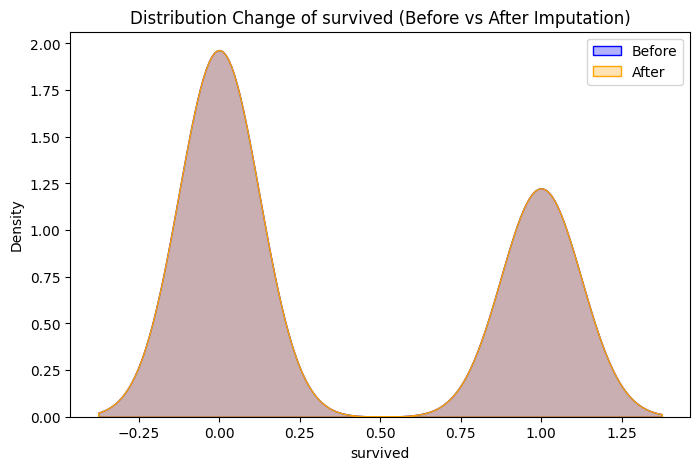

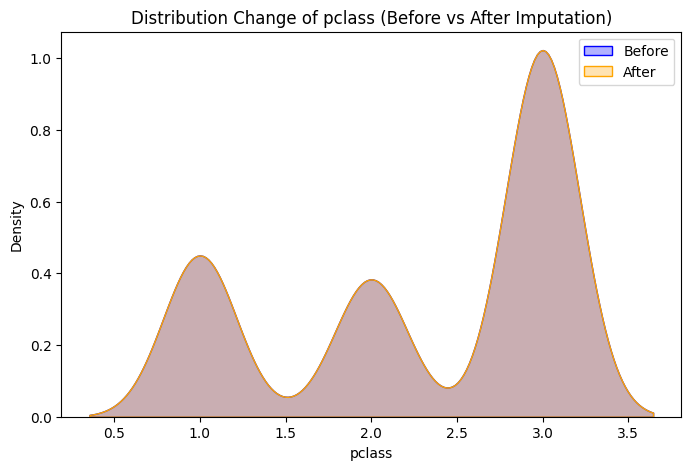

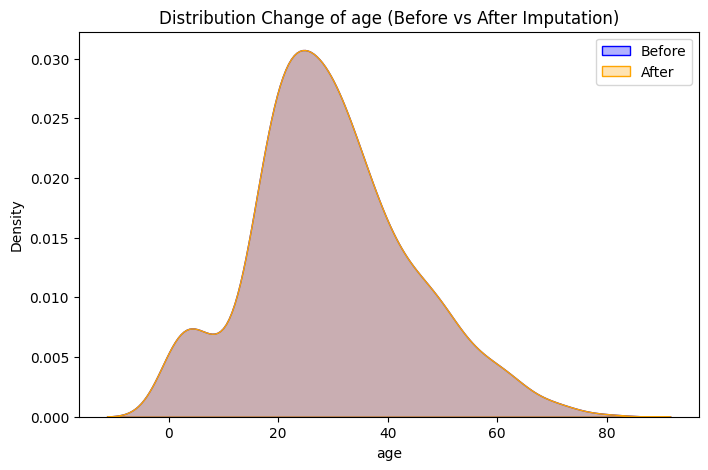

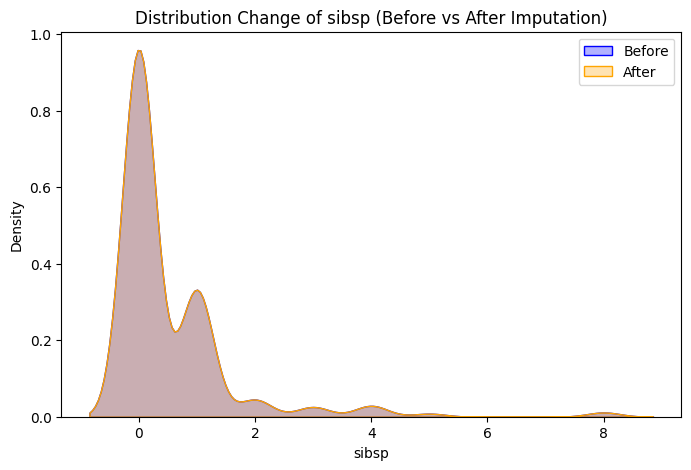

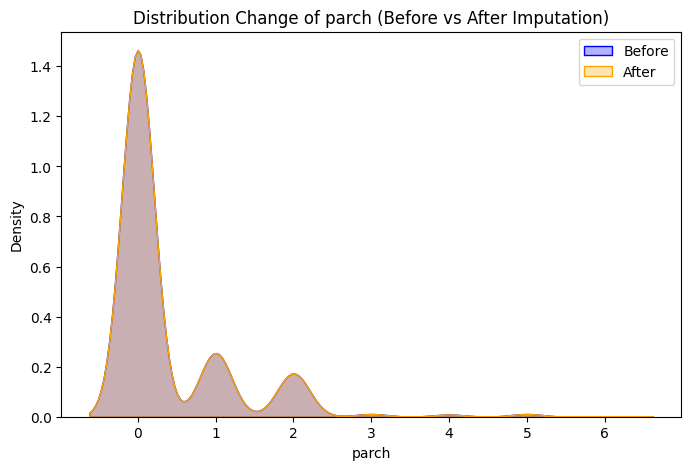

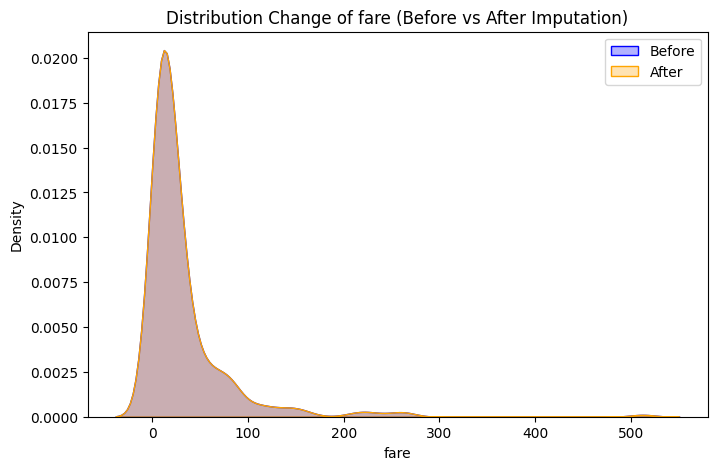

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:

# 5. **결과 비교**
#    - 각 전략별 결측값 개수 확인
#    - 분포 변화 시각화
#    - 통계값 비교
df_processed = df.copy()
for x in df.columns:
    print(f"{x} : {df[x].isnull().sum()}")

for x in ['survived','pclass','age','sibsp','parch','fare',]:
    plt.figure(figsize=(8, 5))
    
    sns.kdeplot(df[x].dropna(), label='Before', color='blue', fill=True, alpha=0.3)
    
    sns.kdeplot(df_processed[x], label='After', color='orange', fill=True, alpha=0.3)

    plt.title(f'Distribution Change of {x} (Before vs After Imputation)')
    plt.xlabel(x)
    plt.ylabel('Density')
    plt.legend()
    plt.show()
df.describe()
